In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Assignment_Dataset.csv (1).csv")
df.head()

Saving Assignment_Dataset.csv.csv to Assignment_Dataset.csv (2).csv


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,32785169,2 Bedroom Refuge with Private Bath & Living Room,20433973,Julia,Bronx,City Island,40.83988,-73.78287,Private room,95,1,6,2019-06-17,1.65,2,359
1,34399984,Two private rooms,259690766,Souadou,Bronx,Belmont,40.85648,-73.88501,Private room,95,2,4,2019-07-01,2.35,1,325
2,36379669,Shared living space in the Bronx!,44378432,Bryan,Bronx,Pelham Bay,40.84735,-73.83095,Shared room,50,1,0,NaN,NaN,1,88
3,35249458,Light-filled comfortable entire apartment,264809787,Kurt,Bronx,Concourse Village,40.82778,-73.91516,Entire home/apt,75,3,2,2019-06-21,2.00,1,253
4,30253236,SedaOn2 Dance Studio,140862407,Angelie,Bronx,Westchester Square,40.84378,-73.84469,Entire home/apt,670,1,2,2019-03-31,0.34,1,178


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4889 non-null   int64  
 1   name                            4886 non-null   object 
 2   host_id                         4889 non-null   int64  
 3   host_name                       4889 non-null   object 
 4   neighbourhood_group             4889 non-null   object 
 5   neighbourhood                   4889 non-null   object 
 6   latitude                        4889 non-null   float64
 7   longitude                       4889 non-null   float64
 8   room_type                       4889 non-null   object 
 9   price                           4889 non-null   int64  
 10  minimum_nights                  4889 non-null   int64  
 11  number_of_reviews               4889 non-null   int64  
 12  last_review                     38

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889000e+03,4.889000e+03,4889.000000,4889.000000,4889.00000,4889.000000,4889.000000,3879.000000,4889.000000,4889.000000
mean,1.902666e+07,6.697190e+07,40.728549,-73.952288,155.46533,6.825731,23.643485,1.399588,6.830027,115.726529
std,1.091048e+07,7.795207e+07,0.054869,0.045684,286.86715,17.227167,43.762044,1.889328,31.722288,132.295573
min,5.803000e+03,2.787000e+03,40.522930,-74.212380,0.00000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.497513e+06,8.138665e+06,40.689760,-73.982950,70.00000,1.000000,1.000000,0.200000,1.000000,0.000000
50%,1.972056e+07,3.028359e+07,40.723060,-73.955720,106.00000,3.000000,5.000000,0.750000,1.000000,50.000000
75%,2.913442e+07,1.072729e+08,40.763060,-73.936710,179.00000,5.000000,24.000000,2.025000,2.000000,235.000000
max,3.648466e+07,2.743115e+08,40.903560,-73.726000,10000.00000,365.000000,447.000000,58.500000,327.000000,365.000000


**Observations**

The dataset contains 4,889 listings across NYC, but two columns — last_review and reviews_per_month — are missing about 1,010 values each. This isn't random: it likely means these listings have never received a review, so there's no review date or frequency to record.

**Cleaning the data**

In [9]:
df["name"] = df["name"].fillna("Unknown")
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)


In [10]:
print("Listings with price = 0:", (df["price"] == 0).sum())
print("Listings with price > 1000:", (df["price"] > 1000).sum())
print("Listings with minimum_nights > 365:", (df["minimum_nights"] > 365).sum())
print("Listings with minimum_nights > 30:", (df["minimum_nights"] > 30).sum())

Listings with price = 0: 4
Listings with price > 1000: 28
Listings with minimum_nights > 365: 0
Listings with minimum_nights > 30: 65


I dropped listings with price = $0 (4 rows) since a real listing can't cost nothing — this is clearly invalid data. I chose to keep listings with high prices (>$1,000) and long minimum stays (>30 nights) since they represent a small fraction of the data and could reflect genuine luxury or long-term listings rather than errors. Without more context, removing them would be an unjustified guess rather than a data-driven decision


In [12]:
df_clean = df[df["price"] > 0].copy()
print("Rows before:", df.shape[0], "| Rows after:", df_clean.shape[0])
df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")
df_clean["last_review"].head(10)

Rows before: 4889 | Rows after: 4885


,last_review
0,2019-06-17
1,2019-07-01
2,NaT
3,2019-06-21
4,2019-03-31
5,NaT
6,2019-04-23
7,2019-07-02
8,2019-07-01
9,2019-07-02


In [13]:
df_clean["price_category"] = pd.cut(
    df_clean["price"],
    bins=[0, 100, 250, df_clean["price"].max()],
    labels=["Budget", "Midrange", "Luxury"]
)

print(df_clean["price_category"].value_counts())

price_category
Budget      2375
Midrange    1990
Luxury       520
Name: count, dtype: int64


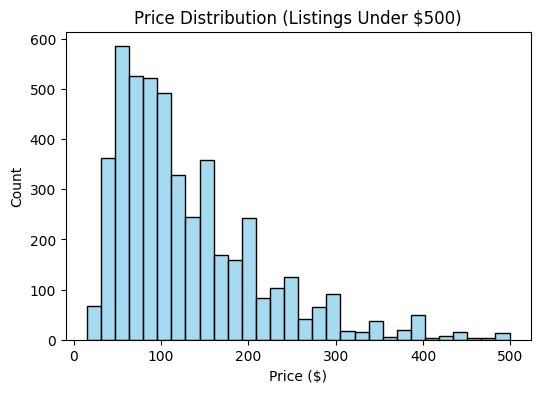

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean[df_clean["price"] < 500]["price"], bins=30, color='skyblue')
plt.title('Price Distribution (Listings Under $500)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

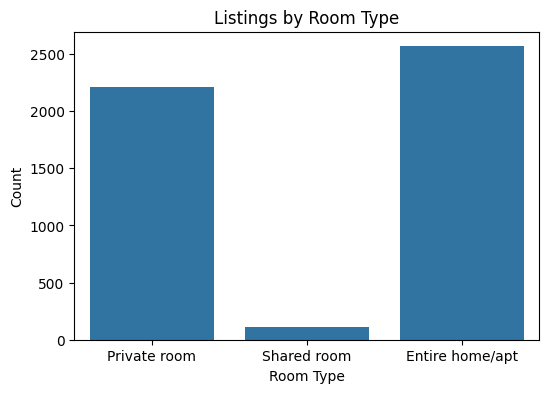

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='room_type', data=df_clean)
plt.title('Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

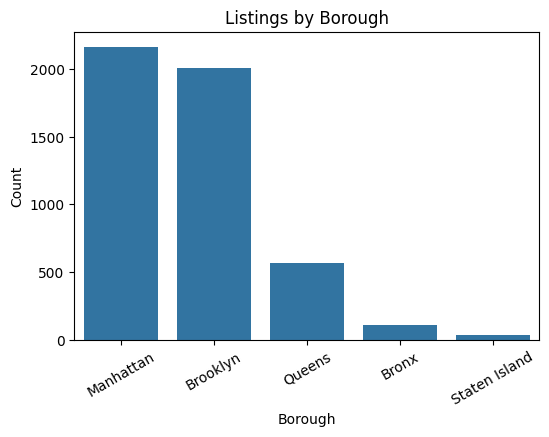

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='neighbourhood_group', data=df_clean, order=df_clean['neighbourhood_group'].value_counts().index)
plt.title('Listings by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

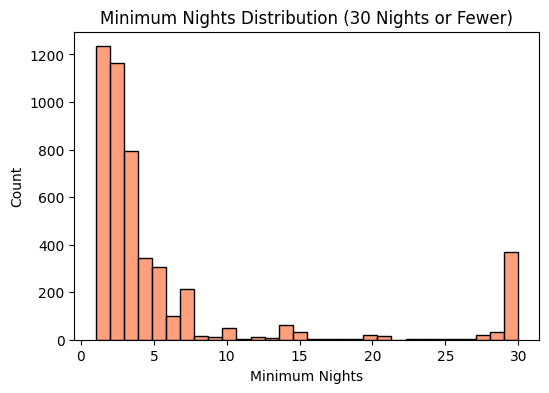

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean[df_clean["minimum_nights"] <= 30]["minimum_nights"], bins=30, color='coral')
plt.title('Minimum Nights Distribution (30 Nights or Fewer)')
plt.xlabel('Minimum Nights')
plt.ylabel('Count')
plt.show()

real data observations :


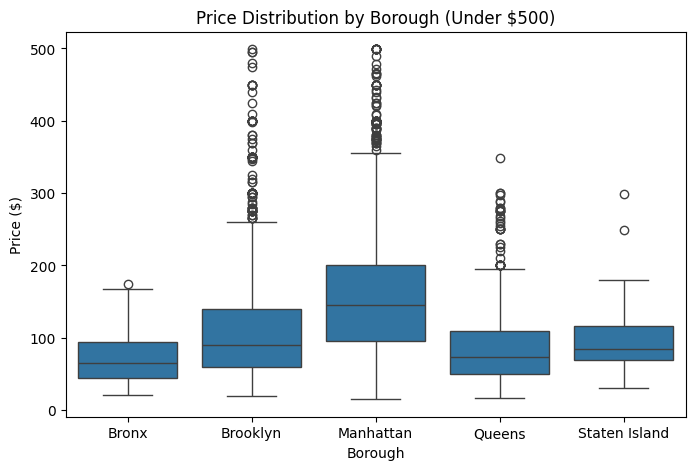

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df_clean[df_clean['price'] < 500])
plt.title('Price Distribution by Borough (Under $500)')
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.show()

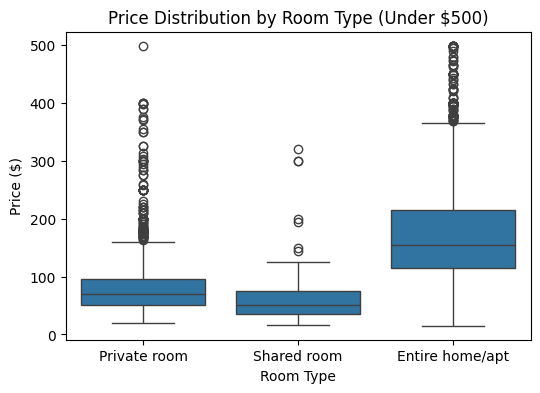

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='room_type', y='price', data=df_clean[df_clean['price'] < 500])
plt.title('Price Distribution by Room Type (Under $500)')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.show()

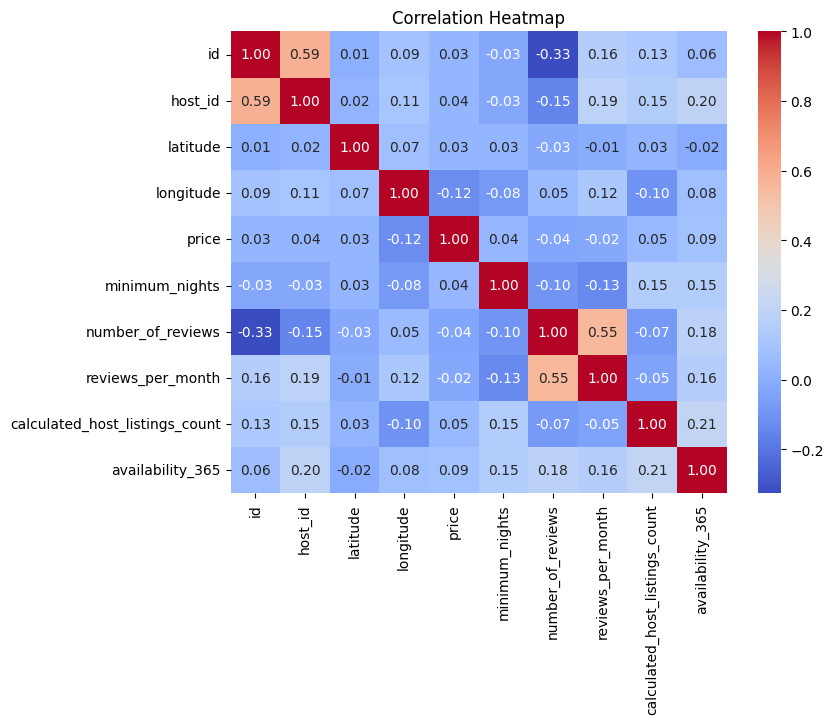

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

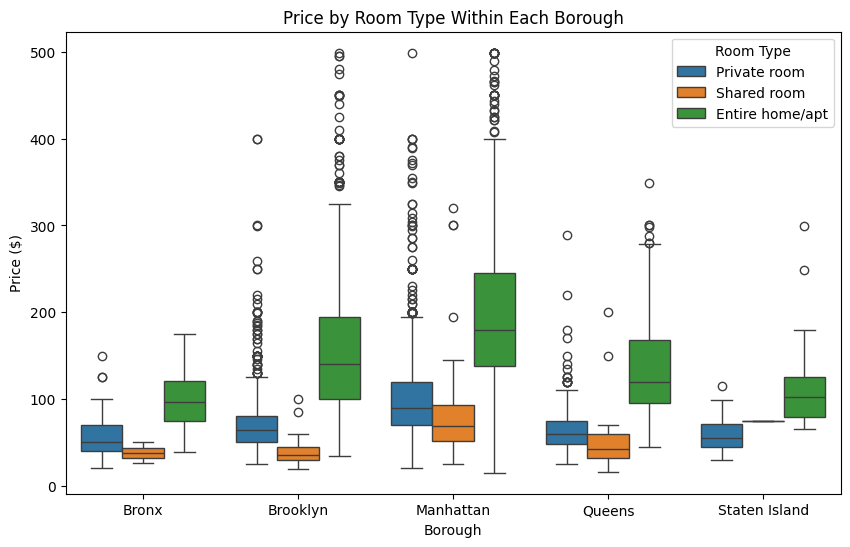

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', hue='room_type', data=df_clean[df_clean['price'] < 500])
plt.title('Price by Room Type Within Each Borough')
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.legend(title='Room Type')
plt.show()

**sumaary of whole work**:


Price is heavily skewed. Most listings are between $70 and $180, but a few luxury listings go up to $10,000, which pulls the average way above the median.

Manhattan and Brooklyn have the most listings by far. Manhattan probably has the single highest count since it's the most popular and busiest borough.
Entire home/apt listings cost the most in every borough, followed by private rooms, then shared rooms. The price gap between entire home and the other types is bigger in Manhattan compared to cheaper boroughs like Bronx or Staten Island.
Around 1,010 listings (about 20%) have no reviews at all. This probably means a good chunk of listings are new or just don't get booked much.
From the correlation heatmap, price didn't correlate strongly with most numeric columns like number_of_reviews. Availability and host listing count had a weak relationship at best. This shows location and room type matter more for price than anything else in the data.
Recommendation: A new host listing an entire home/apt should price based on their specific borough, not a citywide number. In Manhattan they can charge more (around $150-200/night), but the same listing in Bronx should be priced lower to stay competitive, since borough location is one of the biggest price factors here.